# Analiza Danych Obrazowych i Multimedialnych (ADOM)
## Projekt końcowy / Notatnik demonstracyjny

**Metoda:** Detekcja obiektów – Faster R-CNN (2015)  
**Zespół:**  
**Data realizacji:** Maj 2026 r.  

---

## 1. Wprowadzenie do metody Faster R-CNN

**Do czego służy i na czym polega?**
Faster R-CNN (Region-based Convolutional Neural Network) to przełomowa, dwustopniowa architektura głębokich sieci neuronowych służąca do detekcji obiektów na obrazach. Jej celem jest jednoczesna lokalizacja obiektów (wyrysowanie tzw. *bounding boxes*) oraz ich klasyfikacja.

**Główne komponenty (Pipeline):**
1. **Backbone (Ekstraktor cech):** Głęboka sieć konwolucyjna (np. ResNet-50), która przetwarza obraz wejściowy na mapę cech.
2. **Region Proposal Network (RPN):** W pełni konwolucyjna sieć, która na podstawie mapy cech generuje propozycje regionów (*region proposals*), w których z wysokim prawdopodobieństwem znajduje się obiekt. 
3. **RoI Align / Pooling:** Mechanizm wyrównujący wycięte regiony z mapy cech do stałego rozmiaru.
4. **Głowa klasyfikacyjna i regresyjna:** Ostatecznie klasyfikuje zaproponowane regiony i precyzyjnie "doszlifowuje" współrzędne ramek.

**Materiały dodatkowe:**
* [Oryginalny artykuł naukowy (arXiv)](https://arxiv.org/pdf/1506.01497.pdf)
* [Oficjalny tutorial PyTorch](https://pytorch.org/tutorials/intermediate/torchvision_tutorial.html)

## 2. Omówienie wykorzystanej implementacji i Setup Środowiska

W projekcie korzystamy ze środowiska **Python 3** oraz biblioteki **PyTorch / Torchvision**, z której pobieramy architekturę `fasterrcnn_resnet50_fpn`. Na potrzeby eksperymentów doinstalujemy również bibliotekę `ultralytics` (YOLOv8). 

Poniższa komórka przygotowuje urządzenie (akcelerację GPU jeśli dostępna) oraz pobiera wszystkie niezbędne pliki i obrazy.

In [ ]:
# !pip install ultralytics pycocotools -q

import os
import time
import urllib.request
import zipfile
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np

from torchvision.io import read_image
from torchvision.utils import draw_bounding_boxes
import torchvision.transforms.functional as F

%matplotlib inline

# Ustawienie urządzenia (GPU / CPU)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Używane urządzenie: {device}")
print(f"PyTorch version: {torch.__version__}")

os.makedirs('data', exist_ok=True)

# Pobranie obrazów testowych
urls = {
    "data/sample_dog.jpg": "https://raw.githubusercontent.com/pytorch/vision/main/gallery/assets/dog2.jpg",
    "data/hard_case.jpg": "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg"
}

# Bezpieczne pobieranie z nagłówkiem User-Agent
for path, url in urls.items():
    if not os.path.exists(path):
        req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(path, 'wb') as out_file:
            out_file.write(response.read())

# Pobranie skryptów pomocniczych (engine.py, utils.py itp.) z repozytorium PyTorch
files_to_download = ["engine.py", "utils.py", "coco_utils.py", "coco_eval.py", "transforms.py"]
base_url = "https://raw.githubusercontent.com/pytorch/vision/main/references/detection/"
for file_name in files_to_download:
    if not os.path.exists(file_name):
        req = urllib.request.Request(base_url + file_name, headers={'User-Agent': 'Mozilla/5.0'})
        with urllib.request.urlopen(req) as response, open(file_name, 'wb') as out_file:
            out_file.write(response.read())

print("Środowisko gotowe.")

Używane urządzenie: cpu
PyTorch version: 2.12.0+cpu
Środowisko gotowe.


## 3. Prezentacja wyników działania (Inference Pretrained)

Sprawdzamy, jak domyślny, wstępnie wytrenowany model radzi sobie w standardowych (bezproblemowych) warunkach. Zastosujemy wagi `DEFAULT` (zbioru COCO).

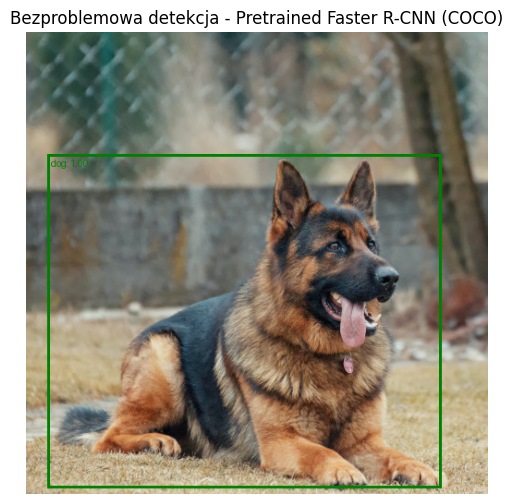

In [ ]:
# Ładowanie modelu z wagami pre-trained na COCO i wysłanie na GPU
weights = torchvision.models.detection.FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model_base = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights).to(device)
model_base.eval() # Tryb ewaluacji

# Wczytanie obrazu i wysłanie na GPU
img = read_image("data/sample_dog.jpg")
img_float = F.convert_image_dtype(img, dtype=torch.float).to(device)

# Predykcja
with torch.no_grad():
    predictions = model_base([img_float])[0]

# Rysowanie bezproblemowych wyników
scores = predictions["scores"].cpu()
boxes = predictions["boxes"].cpu()
labels_idx = predictions["labels"].cpu()

keep = scores > 0.8
boxes_keep = boxes[keep]
labels_keep = [f"{weights.meta['categories'][l]}: {s:.2f}" for l, s in zip(labels_idx[keep], scores[keep])]

result_img = draw_bounding_boxes(img, boxes_keep, labels_keep, colors="green", width=3)

plt.figure(figsize=(10, 6))
plt.imshow(result_img.permute(1, 2, 0))
plt.title("Bezproblemowa detekcja - Pretrained Faster R-CNN (COCO)")
plt.axis("off")
plt.show()

## 4. Krytyczna analiza i weryfikacja eksperymentalna

### Eksperyment 1: Wpływ progu pewności (Confidence Threshold) i NMS
Architektura Faster R-CNN generuje bardzo wiele propozycji z RPN. Parametry `box_score_thresh` oraz `box_nms_thresh` (Non-Maximum Suppression) odpowiadają za filtrowanie tych propozycji. Zobaczmy, co się stanie przy skrajnie błędnych ustawieniach.

Liczba obiektów przy standardowych parametrach (poprzednia sekcja): 3
Liczba obiektów przy 'zepsutych' parametrach (score>0.05, NMS=0.9): 21


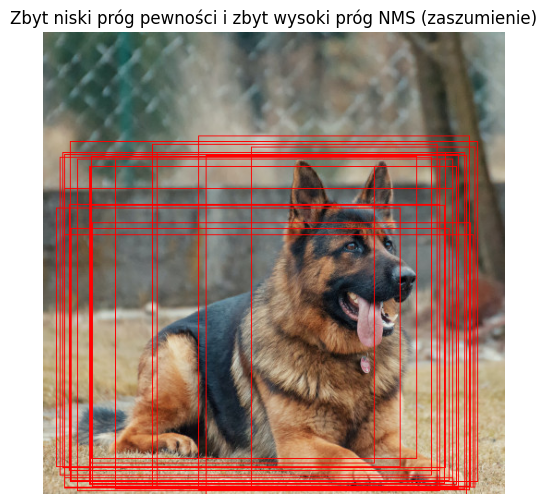

In [ ]:
EXPERIMENT_SCORE_THRESH = 0.05
EXPERIMENT_NMS_THRESHOLD = 0.9

model_exp1 = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=weights,
    box_score_thresh=EXPERIMENT_SCORE_THRESH,
    box_nms_thresh=EXPERIMENT_NMS_THRESHOLD 
).to(device)
model_exp1.eval()

with torch.no_grad():
    preds_exp1 = model_exp1([img_float])[0]

boxes_exp1 = preds_exp1["boxes"].cpu()

print(f"Liczba obiektów przy 'zepsutych' parametrach (score>0.05, NMS=0.9): {len(boxes_exp1)}")

result_img_exp1 = draw_bounding_boxes(img, boxes_exp1, colors="red", width=1)
plt.figure(figsize=(10, 6))
plt.imshow(result_img_exp1.permute(1, 2, 0))
plt.title("Zbyt niski próg pewności i zbyt wysoki próg NMS (zaszumienie)")
plt.axis("off")
plt.show()

## Eksperyment 2: Analiza False Positives (Shift domenowy)
Model Faster R-CNN (z wagami COCO) był trenowany na prawdziwych fotografiach. Kiedy zaprezentujemy mu dane z innej domeny wizualnej – np. obraz artystyczny taki jak "Krzyk" Edvarda Muncha – sieć zaczyna "halucynować". Przy średnim progu ufności (0.3) potrafi wykrywać fałszywe obiekty w abstrakcyjnych plamach farby.

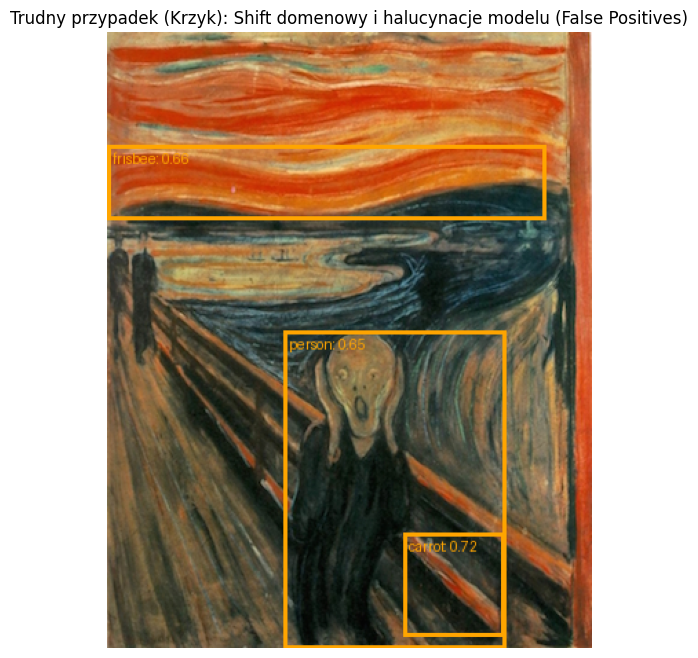

In [6]:
import urllib.request
import os

# Pobieramy obraz sztuki (Krzyk - E. Munch)
scream_path = "data/scream.jpg"
scream_url = "https://raw.githubusercontent.com/pjreddie/darknet/master/data/scream.jpg"

if not os.path.exists(scream_path):
    req = urllib.request.Request(scream_url, headers={'User-Agent': 'Mozilla/5.0'})
    with urllib.request.urlopen(req) as response, open(scream_path, 'wb') as out_file:
        out_file.write(response.read())

img_scream = read_image(scream_path)
img_scream_float = F.convert_image_dtype(img_scream, dtype=torch.float).to(device)

model_base = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights=weights).to(device).eval()

with torch.no_grad():
    preds_scream = model_base([img_scream_float])[0]

# Filtrujemy by uwypuklić błędne detekcje (halucynacje) w nietypowej domenie
keep_scream = preds_scream["scores"] > 0.3
boxes_scream = preds_scream["boxes"][keep_scream].cpu()
scores_scream = preds_scream["scores"][keep_scream].cpu()
labels_scream = [f"{weights.meta['categories'][l]}: {s:.2f}" for l, s in zip(preds_scream["labels"][keep_scream].cpu(), scores_scream)]

result_img_scream = draw_bounding_boxes(img_scream, boxes_scream, labels_scream, colors="orange", width=3)

plt.figure(figsize=(10, 8))
plt.imshow(result_img_scream.permute(1, 2, 0))
plt.title("Trudny przypadek (Krzyk): Shift domenowy i halucynacje modelu (False Positives)")
plt.axis("off")
plt.show()

## Eksperyment 3: Ilościowa Analiza False Positives na zbiorze Pascal VOC (Confusion Matrix)
Zgodnie z dobrymi praktykami w uczeniu maszynowym, model wytrenowany na danym zbiorze (np. COCO) warto przetestować na zupełnie innej dystrybucji danych. Wykorzystamy do tego klasyczny zbiór **Pascal VOC 2012**. 

Ponieważ zbiory te mają różną nomenklaturę, w locie mapujemy 20 klas Pascal VOC na odpowiadające im ID ze zbioru COCO. Obliczymy wieloklasową macierz pomyłek na podzbiorze 100 obrazów walidacyjnych, co pozwoli nam zaobserwować:
* **False Positives (Tło uznane za obiekt)**
* **False Negatives (Pominięte obiekty)**
* **Misklasyfikacje (Np. model COCO myli kota z psem na zdjęciach z Pascal VOC)**

Trwa sprawdzanie i ewentualne pobieranie zbioru Pascal VOC 2012 (ok. 2 GB)...
Analiza 100 obrazów Pascal VOC 2012 i budowa macierzy pomyłek...


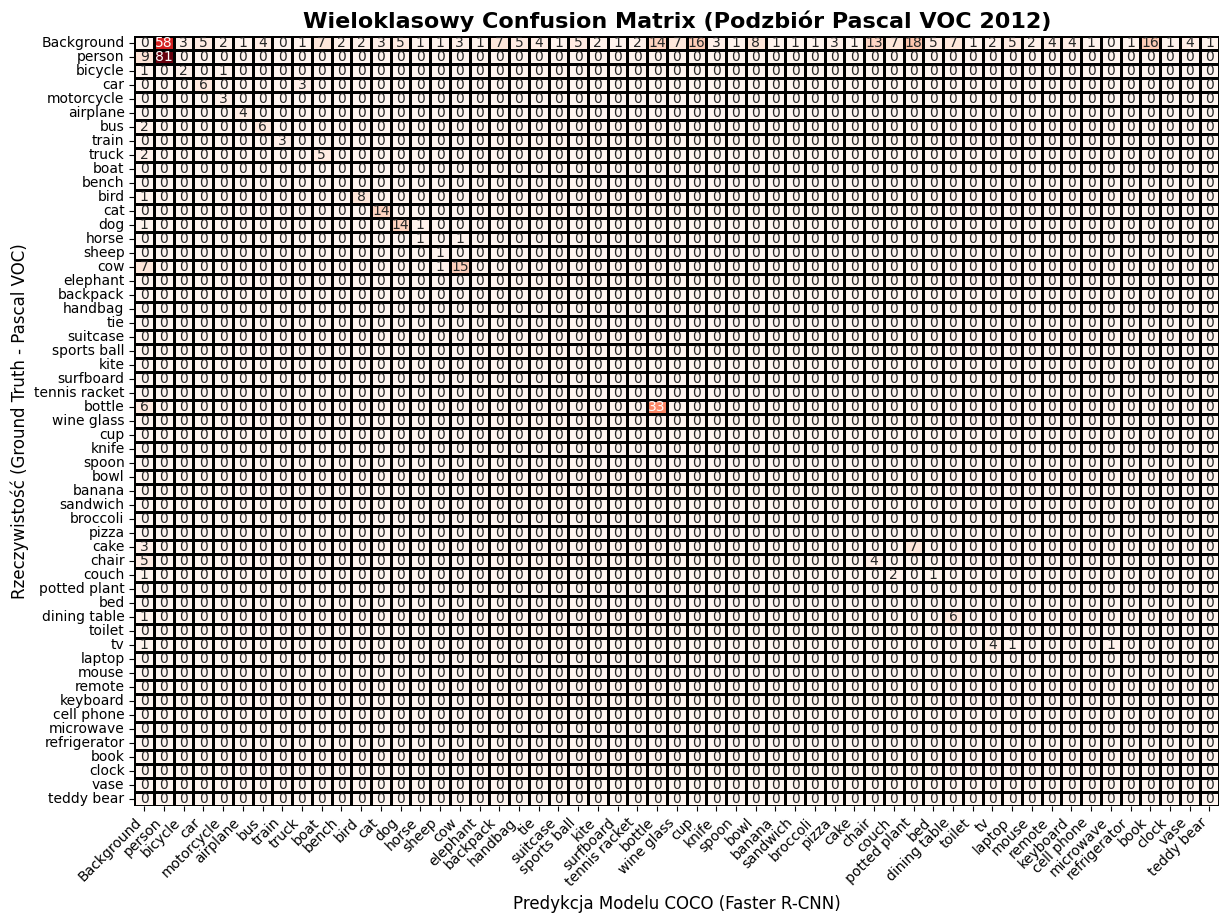

In [ ]:
import torchvision.ops as ops
import seaborn as sns
import pandas as pd
import numpy as np
from collections import defaultdict
import xml.etree.ElementTree as ET # do parsowania Pascal VOC

# Mapowanie klas Pascal VOC (string) -> COCO (int ID)
VOC_TO_COCO_MAP = {
    'person': 1, 'bicycle': 2, 'car': 3, 'motorbike': 4, 'aeroplane': 5, 
    'bus': 6, 'train': 7, 'boat': 8, 'bird': 16, 'cat': 17, 'dog': 18, 
    'horse': 19, 'sheep': 20, 'cow': 21, 'bottle': 44, 'chair': 62, 
    'sofa': 63, 'pottedplant': 61, 'diningtable': 67, 'tvmonitor': 72
}

class PascalVOC_COCO_Adapter(torch.utils.data.Dataset):
    def __init__(self, root, transform=None):
        print("Trwa sprawdzanie i ewentualne pobieranie zbioru Pascal VOC 2012 (ok. 2 GB)...")
        self.voc_dataset = torchvision.datasets.VOCDetection(root=root, year='2012', image_set='val', download=True)
        self.transform = transform

    def __getitem__(self, idx):
        img, target_dict = self.voc_dataset[idx]
        
        boxes = []
        labels = []
        
        # Parsowanie XML-opodobnego słownika z VOC
        objects = target_dict['annotation'].get('object', [])
        if not isinstance(objects, list):
            objects = [objects]
            
        for obj in objects:
            voc_name = obj['name']
            if voc_name in VOC_TO_COCO_MAP:
                labels.append(VOC_TO_COCO_MAP[voc_name])
                bndbox = obj['bndbox']
                boxes.append([float(bndbox['xmin']), float(bndbox['ymin']), float(bndbox['xmax']), float(bndbox['ymax'])])
        
        if len(boxes) == 0:
            # Puste tensory jeśli brak pasujących obiektów
            boxes = torch.empty((0, 4), dtype=torch.float32)
            labels = torch.empty((0,), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        target = {"boxes": boxes, "labels": labels}
        
        # Konwersja PIL Image na Tensor
        img = F.pil_to_tensor(img)
        img = F.convert_image_dtype(img, torch.float32)

        return img, target

    def __len__(self):
        return len(self.voc_dataset)

# Pobranie datasetu
dataset_voc_full = PascalVOC_COCO_Adapter(root='data')

# losowe 100 obrazków
torch.manual_seed(42)
indices = torch.randperm(len(dataset_voc_full))[:100].tolist()
dataset_voc_subset = torch.utils.data.Subset(dataset_voc_full, indices)

data_loader_voc = torch.utils.data.DataLoader(dataset_voc_subset, batch_size=2, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

def compute_advanced_confusion_matrix(model, data_loader, device, iou_threshold=0.5, score_threshold=0.5):
    cm_dict = defaultdict(int)
    model.eval()
    
    with torch.no_grad():
        for images, targets in data_loader:
            images = [img.to(device) for img in images]
            outputs = model(images)
            
            for output, target in zip(outputs, targets):
                pred_boxes = output['boxes'].cpu()
                pred_scores = output['scores'].cpu()
                pred_labels = output['labels'].cpu().tolist()
                
                gt_boxes = target['boxes'].cpu()
                gt_labels = target['labels'].cpu().tolist()
                
                # Odrzucamy słabe predykcje
                keep = pred_scores > score_threshold
                pred_boxes = pred_boxes[keep]
                pred_labels = [l for i, l in enumerate(pred_labels) if keep[i]]
                
                if len(gt_boxes) == 0:
                    for pl in pred_labels: cm_dict[(0, pl)] += 1 
                    continue
                    
                if len(pred_boxes) == 0:
                    for gl in gt_labels: cm_dict[(gl, 0)] += 1
                    continue
                    
                iou_matrix = torchvision.ops.box_iou(gt_boxes, pred_boxes)
                matched_preds = set()
                
                for gt_idx in range(len(gt_boxes)):
                    gl = gt_labels[gt_idx]
                    max_iou, pred_idx = iou_matrix[gt_idx].max(dim=0)
                    pred_idx = pred_idx.item()
                    
                    if max_iou > iou_threshold and pred_idx not in matched_preds:
                        pl = pred_labels[pred_idx]
                        cm_dict[(gl, pl)] += 1 
                        matched_preds.add(pred_idx)
                    else:
                        cm_dict[(gl, 0)] += 1 
                        
                # Pozostałe predykcje to False Positives
                for pred_idx in range(len(pred_boxes)):
                    if pred_idx not in matched_preds:
                        pl = pred_labels[pred_idx]
                        cm_dict[(0, pl)] += 1 
                        
    return cm_dict

print("Analiza 100 obrazów Pascal VOC 2012 i budowa macierzy pomyłek...")
cm_dict = compute_advanced_confusion_matrix(model_base, data_loader_voc, device)

# Zbieranie klas, które realnie pojawiły się w teście
categories = weights.meta["categories"]
categories[0] = "Background"

unique_classes = set([k[0] for k in cm_dict.keys()] + [k[1] for k in cm_dict.keys()])
sorted_classes = sorted(list(unique_classes))
class_names = [categories[i] if i < len(categories) else str(i) for i in sorted_classes]

cm_matrix = np.zeros((len(sorted_classes), len(sorted_classes)), dtype=int)
for (gt, pred), count in cm_dict.items():
    i = sorted_classes.index(gt)
    j = sorted_classes.index(pred)
    cm_matrix[i, j] = count

# Generowanie wykresu
df_cm = pd.DataFrame(cm_matrix, index=class_names, columns=class_names)
plt.figure(figsize=(14, 10))

sns.heatmap(df_cm, annot=True, fmt="d", cmap="Reds", cbar=False, 
            linewidths=1, linecolor='black', 
            xticklabels=True, yticklabels=True)

plt.title("Wieloklasowy Confusion Matrix (Podzbiór Pascal VOC 2012)", fontsize=16, fontweight="bold")
plt.xlabel("Predykcja Modelu COCO (Faster R-CNN)", fontsize=12)
plt.ylabel("Rzeczywistość (Ground Truth - Pascal VOC)", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

### Eksperyment 4: Porównanie z architekturą YOLO (Jednoetapową)
Faster R-CNN to sieć dwuetapowa. Porównajmy czas inferencji z YOLOv8.

In [5]:
try:
    from ultralytics import YOLO
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "ultralytics", "pycocotools", "-q"])
    from ultralytics import YOLO

# Używamy wersji Large (~43.7 mln parametrów) do rzetelnego porównania z ResNet-50 (~41.5 mln)
model_yolo = YOLO('yolov8l.pt') 

_ = model_base([img_float]) # GPU Warmup FasterRCNN
_ = model_yolo("data/sample_dog.jpg", verbose=False) # GPU Warmup YOLO

# Test czasu: Faster R-CNN
start_rcnn = time.time()
with torch.no_grad():
    _ = model_base([img_float])
time_frcnn = (time.time() - start_rcnn) * 1000

# Test czasu: YOLOv8l
start_yolo = time.time()
_ = model_yolo("data/sample_dog.jpg", verbose=False)
time_yolo = (time.time() - start_yolo) * 1000

# Obliczanie parametrów
frcnn_params = sum(p.numel() for p in model_base.parameters())

print("--- PORÓWNANIE ARCHITEKTUR ---")
print(f"Parametry Faster R-CNN (ResNet-50): {frcnn_params / 1e6:.1f} M")
print(f"Parametry YOLOv8l (Large):          ~43.7 M")
print("-" * 30)
print(f"Faster R-CNN Inference Time: {time_frcnn:.2f} ms")
print(f"YOLOv8l Inference Time:      {time_yolo:.2f} ms")
print(f"Różnica: YOLO (architektura jednoetapowa) jest ~{time_frcnn/time_yolo:.1f}x szybsze mimo zbliżonej wielkości modelu.")

--- PORÓWNANIE ARCHITEKTUR ---
Parametry Faster R-CNN (ResNet-50): 41.8 M
Parametry YOLOv8l (Large):          ~43.7 M
------------------------------
Faster R-CNN Inference Time: 802.73 ms
YOLOv8l Inference Time:      332.00 ms
Różnica: YOLO (architektura jednoetapowa) jest ~2.4x szybsze mimo zbliżonej wielkości modelu.


---
## 5. Rozszerzenie GPU: Fine-tuning na własnym zbiorze danych (Penn-Fudan)

Przeprowadzamy transfer learning modelu dla zaledwie 2 klas (Tło + Pieszy) na zbiorze PennFudanPed.
Aby uniknąć długiego trenowania w notatniku demonstracyjnym, kod automatycznie zapisze wagi po wytrenowaniu, a przy kolejnym uruchomieniu po prostu je wczyta.

Znaleziono zapisane wagi! Ładuję wytrenowany model...


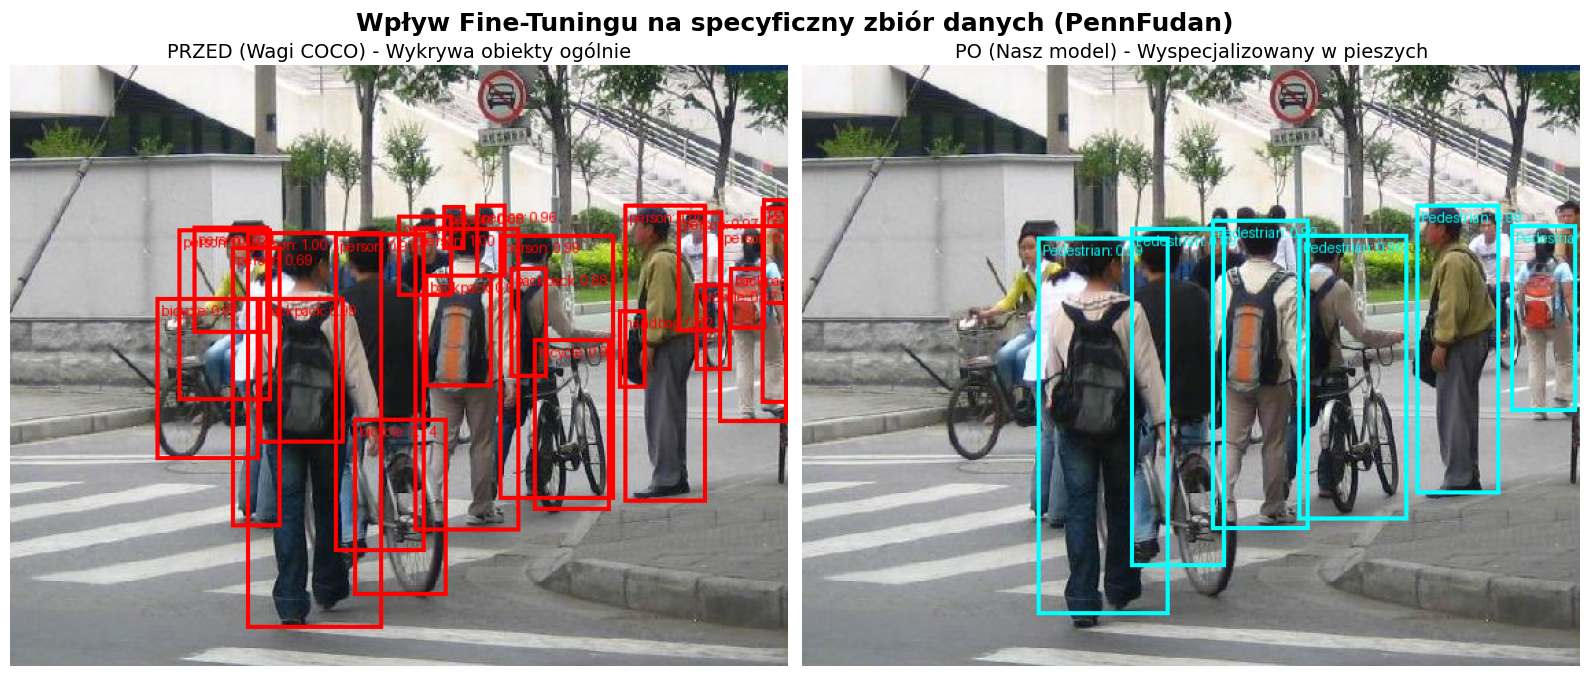

In [ ]:
from torchvision.transforms import v2 as T
from torchvision import tv_tensors
from torchvision.ops.boxes import masks_to_boxes
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
import utils
from engine import train_one_epoch, evaluate

# Pobranie zbioru danych PennFudan
dataset_path = "data/PennFudanPed"
if not os.path.exists(dataset_path):
    print("Pobieram zbiór danych PennFudanPed...")
    urllib.request.urlretrieve("https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip", dataset_path + ".zip")
    with zipfile.ZipFile(dataset_path + ".zip", 'r') as zip_ref:
        zip_ref.extractall('data')

# Definicja klasy Dataset
class PennFudanDataset(torch.utils.data.Dataset):
    def __init__(self, root, transforms):
        self.root = root
        self.transforms = transforms
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = read_image(img_path)
        mask = read_image(mask_path)
        
        obj_ids = torch.unique(mask)[1:]
        masks = (mask == obj_ids[:, None, None]).to(dtype=torch.uint8)
        boxes = masks_to_boxes(masks)
        labels = torch.ones((len(obj_ids),), dtype=torch.int64)
        
        img = tv_tensors.Image(img)
        
        target = {
            "boxes": tv_tensors.BoundingBoxes(boxes, format="XYXY", canvas_size=img.shape[-2:]),
            "masks": tv_tensors.Mask(masks),
            "labels": labels,
            "image_id": idx,
            "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
            "iscrowd": torch.zeros((len(obj_ids),), dtype=torch.int64)
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        return img, target

    def __len__(self):
        return len(self.imgs)
    
# Modyfikacja architektury (zmiana klasyfikatora na 2 klasy)
def get_model_instance_segmentation(num_classes):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

def get_transform(train):
    transforms = []
    if train:
        transforms.append(T.RandomHorizontalFlip(0.5))
    transforms.append(T.ToDtype(torch.float, scale=True))
    transforms.append(T.ToPureTensor())
    return T.Compose(transforms)

# Inicjalizacja modelu
num_classes = 2
model_ft = get_model_instance_segmentation(num_classes).to(device)
weights_file = "faster_rcnn_pennfudan.pth"

# Trenowanie lub Ładowanie Wag
if os.path.exists(weights_file):
    print("Znaleziono zapisane wagi! Ładuję wytrenowany model...")
    model_ft.load_state_dict(torch.load(weights_file, map_location=device, weights_only=True))
else:
    print("Brak zapisanych wag. Rozpoczynam trenowanie (GPU)...")
    dataset = PennFudanDataset('data/PennFudanPed', get_transform(train=True))
    dataset_test = PennFudanDataset('data/PennFudanPed', get_transform(train=False))

    indices = torch.randperm(len(dataset)).tolist()
    dataset = torch.utils.data.Subset(dataset, indices[:-50])
    dataset_test = torch.utils.data.Subset(dataset_test, indices[-50:])

    data_loader = torch.utils.data.DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=utils.collate_fn)
    data_loader_test = torch.utils.data.DataLoader(dataset_test, batch_size=1, shuffle=False, collate_fn=utils.collate_fn)

    params = [p for p in model_ft.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.1)

    for epoch in range(2):
        train_one_epoch(model_ft, optimizer, data_loader, device, epoch, print_freq=10)
        lr_scheduler.step()
        evaluate(model_ft, data_loader_test, device=device)
        
    torch.save(model_ft.state_dict(), weights_file)
    print(f"Trenowanie zakończone. Zapisano wagi do {weights_file}")

# Wizualizacja prze i po transfer learningu
model_ft.eval()
test_img = read_image("data/PennFudanPed/PNGImages/FudanPed00046.png")
test_tensor = T.ToPureTensor()(T.ToDtype(torch.float, scale=True)(test_img)).to(device)

# predykcja przed
with torch.no_grad():
    pred_base = model_base([test_tensor])[0]

keep_base = pred_base["scores"] > 0.6
boxes_base = pred_base["boxes"][keep_base].cpu()
labels_base = [f"{weights.meta['categories'][l]}: {s:.2f}" for l, s in zip(pred_base["labels"][keep_base].cpu(), pred_base["scores"][keep_base].cpu())]
res_img_base = draw_bounding_boxes(test_img, boxes_base, labels_base, colors="red", width=3)

# predykcja po
with torch.no_grad():
    pred_ft = model_ft([test_tensor])[0]

keep_ft = pred_ft["scores"] > 0.6
boxes_ft = pred_ft["boxes"][keep_ft].cpu()
labels_ft = [f"Pedestrian: {s:.2f}" for s in pred_ft["scores"][keep_ft].cpu()]
res_img_ft = draw_bounding_boxes(test_img, boxes_ft, labels_ft, colors="cyan", width=3)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Wpływ Fine-Tuningu na specyficzny zbiór danych (PennFudan)", fontsize=18, fontweight='bold')

axes[0].imshow(res_img_base.permute(1, 2, 0))
axes[0].set_title("PRZED (Wagi COCO) - Wykrywa obiekty ogólnie", fontsize=14)
axes[0].axis("off")

axes[1].imshow(res_img_ft.permute(1, 2, 0))
axes[1].set_title("PO (Nasz model) - Wyspecjalizowany w pieszych", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 6. Wnioski końcowe
1. **Zastosowanie:** Faster R-CNN idealnie sprawdza się w zadaniach wymagających wysokiej precyzji, szczególnie w przypadku obiektów małych lub znajdujących się w nietypowym zagęszczeniu. Architektura ta stanowi też doskonałą bazę do rozszerzeń segmentacyjnych (np. Mask R-CNN).
2. **Ograniczenia:** Aplikacje *Real-time* na urządzeniach brzegowych. Testy potwierdziły, że czas inferencji sieci dwuetapowej znacząco ustępuje metodom jednoetapowym (jak YOLO).
3. **Parametry:** RPN jest niezwykle wrażliwy na parametry post-processingu (NMS i Confidence Threshold) – ich niewłaściwy dobór powoduje zalew fałszywych detekcji i duplikatów.